In [ ]:
from utils import generals
import pandas as pd
import os
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import iplot
from scipy.fftpack import fft
from importlib import reload
import gc

origin = None
train = None
wws = None
hpc = None
hpt = None
esns = None
sensors = None
points = None

def check_init():
    global origin, train, wws, hpc, hpt, esns, sensors, points
    reload(generals)
    origin = generals.load_training()
    train = origin.dropna().copy() #757 righe in meno
    gc.collect() 
    esns = generals.ESN.copy()
    sensors = generals.SENSORS.tolist()

    wws = generals.get_shift('Cumulative_WWs', train)
    hpc = generals.get_shift('Cumulative_HPC_SVs', train)
    hpt = generals.get_shift('Cumulative_HPT_SVs', train)

    points = {"HPT": hpt, "HPC": hpc, "WWs": wws}

check_init()

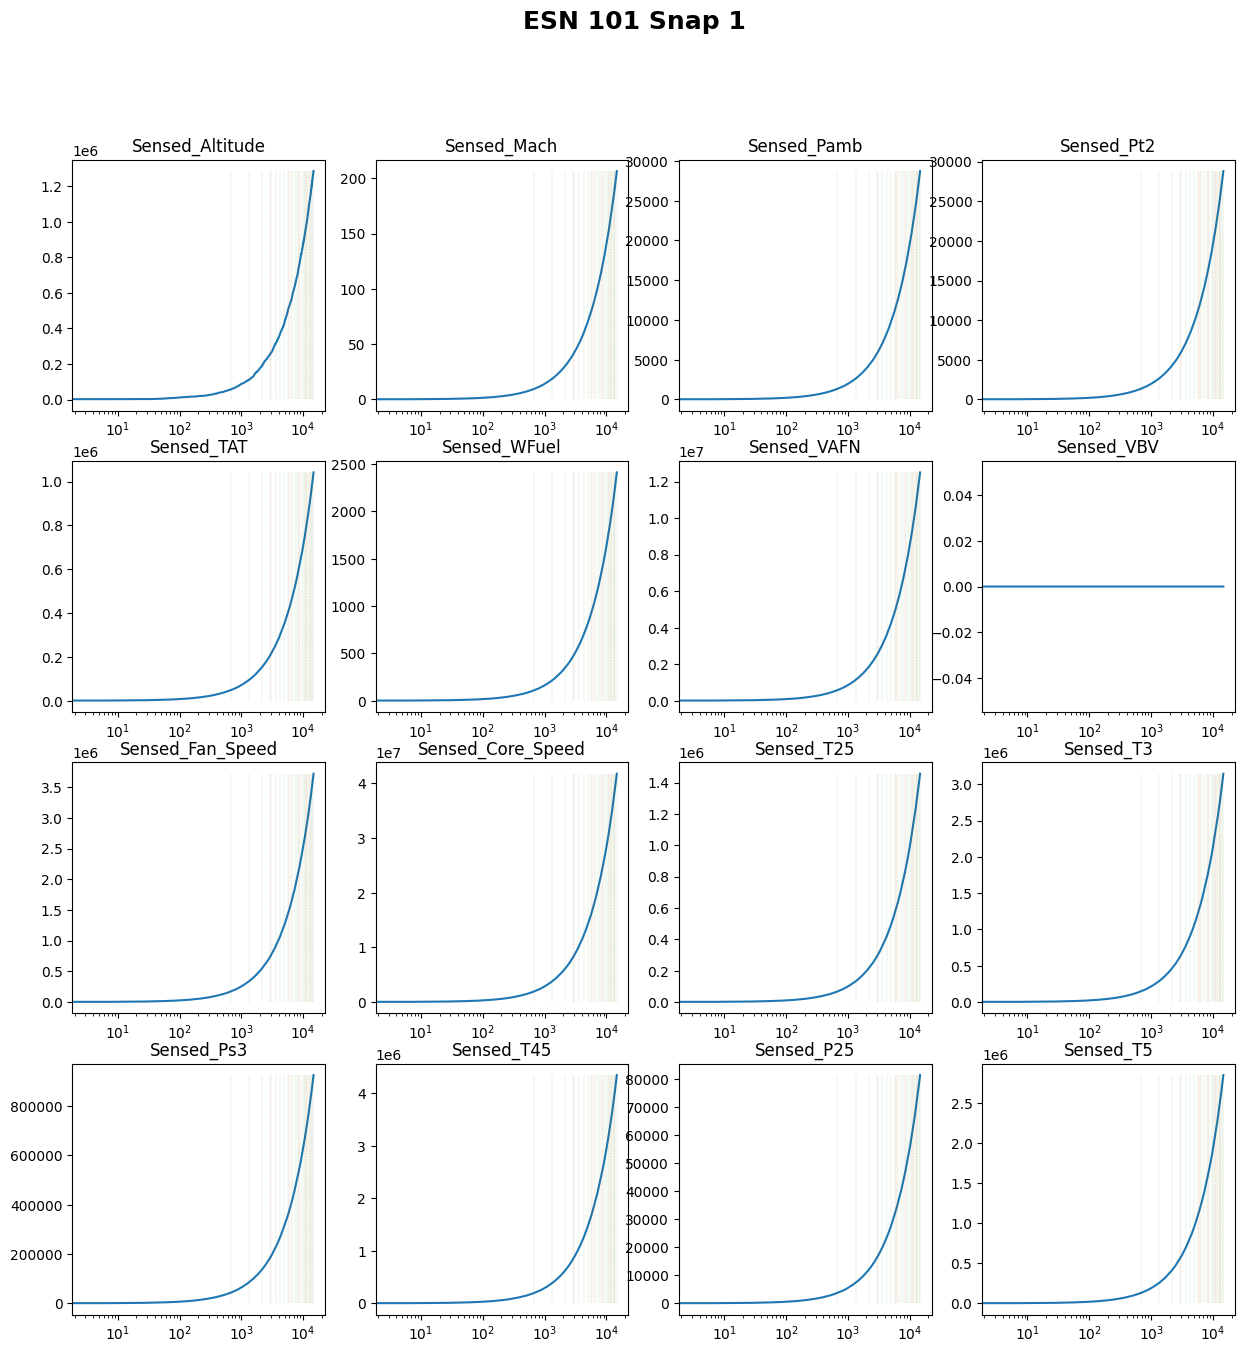

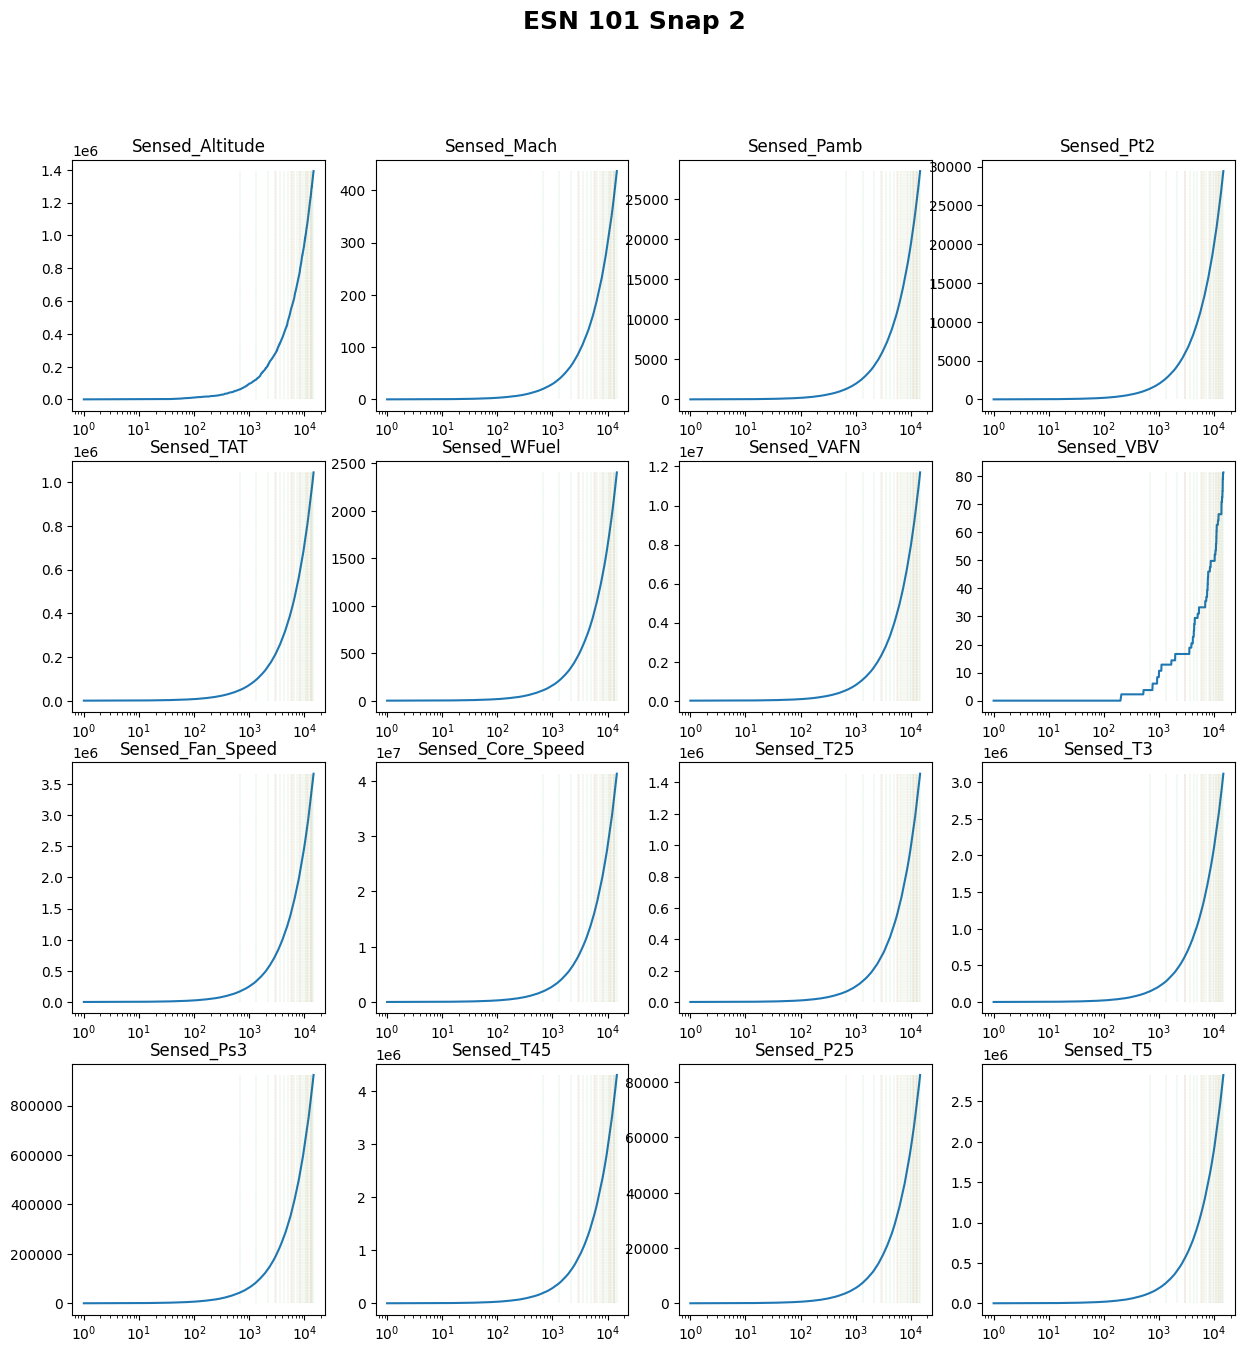

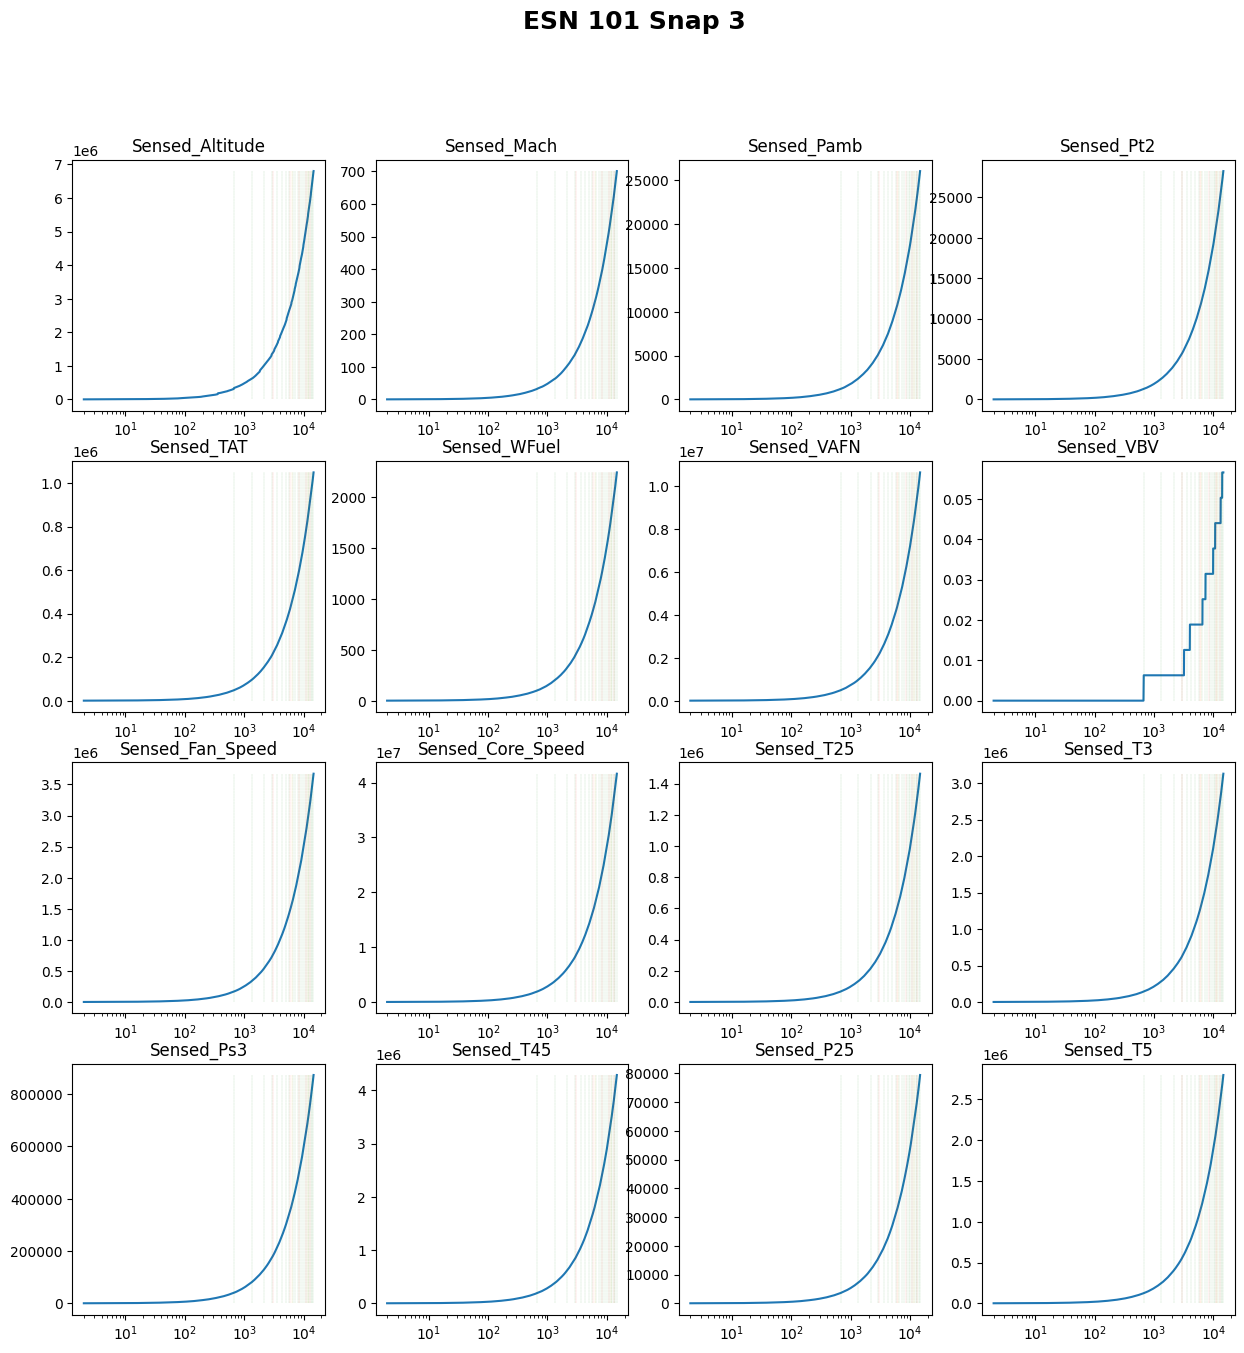

KeyboardInterrupt: 

In [54]:
check_init()

point_colors = ['red', 'orange', 'green', 'purple']
def plot():
    fig, axs = plt.subplots(4,4, figsize=(15,15))
    for i, sensor in enumerate(generals.SENSORS.iter()):
        c = i%4
        r = i//4
        df = generals.filter(generals.filter(train, "ESN", esn), "Snapshot", snap)
        cumsum = df[sensor].cumsum()
        axs[r,c].plot(cumsum.index, cumsum, label=sensor)
        axs[r,c].set_title(sensor)
        axs[r,c].set_xscale('log')
        for p_idx, (plabel, p_data) in enumerate(points.items()):
            color = point_colors[p_idx % len(point_colors)]
            current_points = p_data.loc[p_data['ESN'] == esn]
            if not current_points.empty:
                axs[r,c].vlines(
                    x=current_points.index,
                    ymin=cumsum.min(),
                    ymax=cumsum.max(),
                    colors=color,
                    linestyles='dashed',
                    label=plabel,
                    alpha=0.9,
                    linewidth=0.1
                )

    fig.suptitle(f'ESN {esn} Snap {snap}', fontsize=18, fontweight='bold')
    plt.show()

for esn in generals.ESN:
    for snap in range(1,9):
        plot()

In [ ]:
check_init()

point_colors = ['red', 'orange', 'green', 'purple']
def plot():
    plt.figure(figsize=(15,15))
    df = generals.filter(generals.filter(train, "ESN", esn), "Snapshot", snap)
    cumsum = df[sensor].cumsum()
    plt.plot(cumsum.index, cumsum)
    for p_idx, (plabel, p_data) in enumerate(points.items()):
        color = point_colors[p_idx % len(point_colors)]
        current_points = p_data.loc[p_data['ESN'] == esn]
        if not current_points.empty:
            plt.vlines(
                x=current_points.index,
                ymin=cumsum.min(),
                ymax=cumsum.max(),
                colors=color,
                linestyles='dashed',
                label=plabel,
                alpha=0.9,
                linewidth=0.1
            )
    plt.show()

for esn in generals.ESN:
    for snap in range(1,9):
        sensor = generals.SENSORS.Sensed_Pamb.value
        plot()

### NOTA: La rolling window è nel file ROLLING

# Analisi nel tempo
- rolling window (ROLLING.ipynb)
- EWMA
- regressione